# Introduction to Data Science 2026

# Week 5

## Exercise 1 | Privacy and data protection

First, look up the [European Data Protection Regulation](http://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32016R0679&from=en) (“GDPR”). Note that Articles 1-99 start on p. 32 of the document. We will refer to the articles and their parts by, e.g., “Art 6 (1) a) GDPR” which means Article 6 (“Lawfulness of processing”), first paragraph, item a in the GDPR.

1. Valid Consent?

    Find a service you use to which you have given *consent* for the processing of your personal data (Art 6 (1) a) GDPR). Have a look at the privacy notices, policies, or settings of this service.

    - Are the basic legal conditions for this consent in your opinion in line with the new requirements and conditions set by the GDPR?

    - You should provide an answer with justification based on the GDPR, where you refer to specific articles and paragraphs.

2. Your Right to Access your Personal Data

    You have the right to know if personal data about you is processed by a controller. You also have the right to get access to, for example, the processing purposes, the data categories, data transfers, and duration of storage.

    - Find the relevant parts in GDPR and study your rights as a “data subject”.

    - File a right-to-access request with a data processing service of your choosing. Describe the mechanism that is put in place by the service to enable you to exercise this right (if any).

    - Whether you get a response or not, think about how well your rights as a data subject are respected in practice. Your answer should again refer to specific articles and paragraphs of the GDPR.

3. Anonymisation & Pseudonymisation

    - What is the difference between anonymisation and pseudonymisation of personal data?

**Submit your findings in a PDF file, just a short report is enough.**

## Exercise 2 | Fairness-aware AI

This template generates data about the working hours and salaries of n=5000 people. The salary equals 100 x working hours plus/minus normal distributed noise. If you run the template, it produces an _hours_ vs _monthly salary_ scatter plot with gender=0 (men) in orange and gender=1 (women) in orange. The plot includes a trend line for each group, and an overall trend line for all data combined (in red). 

A linear regression model (see the next code cell) that only includes the working hours as a covariate *without* the protected characteristic (gender) should have slope close to 100.0.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### Simulating the data

In [2]:
#sample size n
n = 5000

# gender
gen = np.random.binomial(1, 0.5, size=n)

# work hours
hrs = np.random.binomial(60, 0.5, size=n)

# salary = 100 * hours + noise (std.deviation 10)
sal = hrs * np.random.normal(100, 10, size=n) 

# create a nice data frame
data = pd.DataFrame({"Gender": gen, "Hours": hrs, "Salary": sal})

### Scatterplot of the simulated data
Women samples (gender = 1) are shown with blue, men samples (gender = 0) are shown in orange.
Blue and orange lines are the trend lines of each group accordingly.
The overall trend line is shown in red.

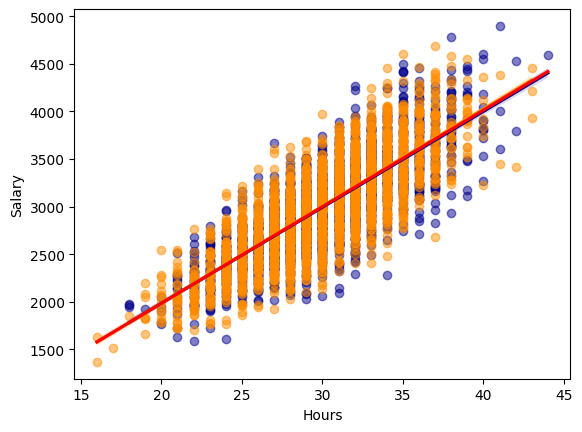

In [3]:
sns.regplot(x="Hours", y="Salary", data=data[data["Gender"]==1], color="darkBlue", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data[data["Gender"]==0], color="darkOrange", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data, marker="None", color="red")

plt.show()

### Linear regression
Learn the overall regression model, which is what an algorithm with no access to the gender ("protected characteristic") would learn from the data.

In [4]:
reg = LinearRegression().fit(hrs.reshape(-1,1), sal.reshape(-1,1))

# print out the slope: it should be close to 100.0 without learning the 'protected characteristic' (gender)
print("slope: %.1f" % reg.coef_[0][0])

slope: 101.4


### Task

Now edit the code to simulate each of the following scenarios:

a) the salary of women is reduced by 200 euros ("direct discrimination")

b) the working hours of men are binomially distributed with parameters (60, 0.55) while the working hours of women are binomially distributed with parameters (60, 0.45), no changes in per-hour salary ("no discrimination")

c) both of the above changes at the same time ("indirect discrimination")

You should be able to demonstrate that the slope of the linear regression model is only changed in one of these scenarios.

Based on this experiment, answer the following questions:
1. In which of the scenarios the slope (coefficient) of the regression model changes?
2. How could you model the data in a way that enables you to detect indirect discrimination? _Hint_: Should you include the protected characteristic in the model or not?

To answer the second question, demonstrate your solution by building a regression model and interpreting the estimated coefficients.

**Submit this exercise by submitting your code and your answers to the above questions on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

In [5]:
np.random.seed(0)  # reproducibility

n = 5000
gen = np.random.binomial(1, 0.5, size=n)
hrs = np.random.binomial(60, 0.5, size=n)

# Salary = 100 * hours + noise, MINUS 200 if gender == 1 (women)
sal_a = hrs * np.random.normal(100, 10, size=n) - (gen * 200)

data_a = pd.DataFrame({"Gender": gen, "Hours": hrs, "Salary": sal_a})

# Regression WITHOUT gender (what an algorithm blind to gender would learn)
reg_a = LinearRegression().fit(hrs.reshape(-1,1), sal_a.reshape(-1,1))
print("Scenario a) direct discrimination — slope:", reg_a.coef_[0][0])

Scenario a) direct discrimination — slope: 100.8743538393981


In [6]:
np.random.seed(0)

n = 5000
gen = np.random.binomial(1, 0.5, size=n)

# Hours: men ~ Binomial(60, 0.55), women ~ Binomial(60, 0.45)
hrs_b = np.where(
    gen == 0,
    np.random.binomial(60, 0.55, size=n),  # men
    np.random.binomial(60, 0.45, size=n)   # women
)

# Salary = 100 * hours + noise, NO gender-based adjustment
sal_b = hrs_b * np.random.normal(100, 10, size=n)

data_b = pd.DataFrame({"Gender": gen, "Hours": hrs_b, "Salary": sal_b})

reg_b = LinearRegression().fit(hrs_b.reshape(-1,1), sal_b.reshape(-1,1))
print("Scenario b) no discrimination — slope:", reg_b.coef_[0][0])

Scenario b) no discrimination — slope: 99.46011946433596


In [7]:
np.random.seed(0)

n = 5000
gen = np.random.binomial(1, 0.5, size=n)

# Hours: same as scenario b) -- men work more hours on average than women
hrs_c = np.where(
    gen == 0,
    np.random.binomial(60, 0.55, size=n),
    np.random.binomial(60, 0.45, size=n)
)

# Salary: same as scenario a) -- 100/hour, minus 200 flat if woman
sal_c = hrs_c * np.random.normal(100, 10, size=n) - (gen * 200)

data_c = pd.DataFrame({"Gender": gen, "Hours": hrs_c, "Salary": sal_c})

reg_c = LinearRegression().fit(hrs_c.reshape(-1,1), sal_c.reshape(-1,1))
print("Scenario c) indirect discrimination — slope:", reg_c.coef_[0][0])

Scenario c) indirect discrimination — slope: 112.07843600482619


In [8]:
# Regression on scenario c) data, but WITH gender included as a covariate
X_c = data_c[["Hours", "Gender"]]
y_c = data_c["Salary"]

reg_c_full = LinearRegression().fit(X_c, y_c)

print("Coefficient for Hours:", reg_c_full.coef_[0])
print("Coefficient for Gender:", reg_c_full.coef_[1])

Coefficient for Hours: 99.2954422762561
Coefficient for Gender: -202.61012929183462


## Results and analysis

I simulated the three scenarios described in the task, keeping the random seed fixed
across simulations so results are directly comparable, and fit a linear regression of
Salary on Hours (without Gender) in each case, exactly as an algorithm blind to the
protected characteristic would.

### Slope comparison

| Scenario | Description | Slope |
|---|---|---|
| Baseline | No discrimination (original template) | ~100 |
| a) Direct discrimination | Women's salary reduced by a flat 200 euros | 100.87 |
| b) No discrimination | Men ~ Binomial(60, 0.55) hours, women ~ Binomial(60, 0.45) hours, same pay/hour | 99.46 |
| c) Indirect discrimination | a) and b) combined | **112.08** |

### Question 1 -- In which scenario does the slope change?

Only in scenario c). In scenario a), the 200 euro penalty is a flat deduction that does
not depend on hours worked, so it only shifts the regression line's intercept, not its
slope. In scenario b), hours differ by gender but pay per hour is identical for both
groups, so the hours-to-salary relationship the model learns is still correct. It is
only when both effects are combined (scenario c) that the slope becomes distorted
(112.08 instead of ~100): because women already work fewer hours on average, a flat
penalty applied to that same group ends up looking, statistically, like a smaller
per-hour rate concentrated at the low end of the hours range. Since gender is not in
the model, the regression has no way to represent this and instead compensates by
inflating the overall slope. This is Simpson's paradox / indirect discrimination in
action: gender is correlated with an included variable (hours), so its effect leaks
into that variable's coefficient instead of disappearing.

### Question 2 -- How can indirect discrimination be detected?

Counterintuitively, the protected characteristic (gender) should be *included* as a
covariate -- not in order to discriminate, but in order to audit for discrimination.
Fitting a regression of Salary on both Hours and Gender for the scenario c) data gives:

- Coefficient for Hours: 99.30 (back to the correct ~100 euros/hour rate)
- Coefficient for Gender: -202.61 (very close to the actual -200 euro penalty that was
  simulated)

By explicitly modeling Gender, the regression can separate the legitimate effect of
hours worked from the discriminatory effect of gender, recovering both the true hourly
rate and a precise estimate of the discrimination itself. A model that simply excludes
the protected attribute is not "fair" by default -- it can fail to detect indirect
discrimination entirely, and can even produce biased estimates of other, seemingly
unrelated coefficients (as seen with the inflated 112.08 slope). This connects directly
to the redlining problem covered in this week's readings: removing a sensitive
attribute does not remove its effect on the data whenever it correlates with variables
that remain in the model -- it can simply hide that effect inside another coefficient
instead of eliminating it.